# 📓 BlackBox AutoML Report — Telco-Customer-ChurnThis notebook was **automatically generated** by BlackBox AutoML. It contains the complete machine learning pipeline: from data loading and cleaning through model evaluation and recommendations.---

## 📋 Step 1: Data Loading & CleansingIn this section, we load the dataset and perform initial data cleaning. Cleaning is a critical step in any machine learning pipeline — it ensures the data is consistent, complete, and ready for modeling.

In [ ]:
# Load the datasetimport pandas as pdimport numpy as npimport warningswarnings.filterwarnings('ignore')# Display basic informationprint(f"Dataset shape: {(7043, 21)}")print(f"Number of columns: {(7043, 21)[1]}")print(f"Number of rows: {(7043, 21)[0]}")print(f"Number of duplicates: {0}")print(f"Columns and their data types:")for col, dtype in info['dtypes'].items():    print(f"  - {col}: {dtype}")

Dataset shape: (7043, 21)
Number of columns: 21
Number of rows: 7043
Number of duplicates: 0

Columns and their data types:
  - customerID: object
  - gender: object
  - SeniorCitizen: int64
  - Partner: object
  - Dependents: object
  - tenure: int64
  - PhoneService: object
  - MultipleLines: object
  - InternetService: object
  - OnlineSecurity: object
  - OnlineBackup: object
  - DeviceProtection: object
  - TechSupport: object
  - StreamingTV: object
  - StreamingMovies: object
  - Contract: object
  - PaperlessBilling: object
  - PaymentMethod: object
  - MonthlyCharges: float64
  - TotalCharges: object
  - Churn: object

### 📄 First 5 Rows of the DatasetLet's take a peek at the first few rows to understand the data structure.

In [ ]:
# Display first 5 rowsdf.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 🧹 Handling Missing ValuesMissing values can cause issues with many machine learning algorithms. We handle them using appropriate strategies:- **Numerical columns**: fill with median (robust to outliers)- **Categorical columns**: fill with mode (most frequent value)

### 🔄 Removing DuplicatesRemoved 0 duplicate rows. Rows before: 7043, after: 7043.

### 📊 Outlier Detection & TreatmentOutliers can skew the model's learning. We use the **IQR (Interquartile Range)** method to detect and cap extreme values.**Results:**- Column 'SeniorCitizen': capped 1142 outliers at [0.0000, 0.0000].- Column 'tenure': capped 0 outliers at [-60.0000, 124.0000].- Column 'MonthlyCharges': capped 0 outliers at [-46.0250, 171.3750].

### ✅ Data Cleaning CompleteThe dataset now has **7043 rows** and **21 columns**, ready for the next steps.

## 📊 Step 2: Exploratory Data Analysis (EDA)EDA helps us understand patterns, relationships, and distributions in the data. We'll visualize key aspects to gain insights.

### 📈 Statistical SummaryBasic statistical measures for numerical columns (count, mean, std, min, max, quartiles).

In [ ]:
# Statistical summarydf.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.0,7043,7043,7043.00,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.00,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.0,NaN,NaN,32.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.76,NaN,NaN
std,NaN,NaN,0.0,NaN,NaN,24.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.09,NaN,NaN
min,NaN,NaN,0.0,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.25,NaN,NaN
25%,NaN,NaN,0.0,NaN,NaN,9.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.50,NaN,NaN
50%,NaN,NaN,0.0,NaN,NaN,29.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.35,NaN,NaN
75%,NaN,NaN,0.0,NaN,NaN,55.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.85,NaN,NaN


### 🔥 Correlation HeatmapCorrelation shows how features relate to each other. Values near +1 or -1 indicate strong relationships, while values near 0 indicate weak relationships.

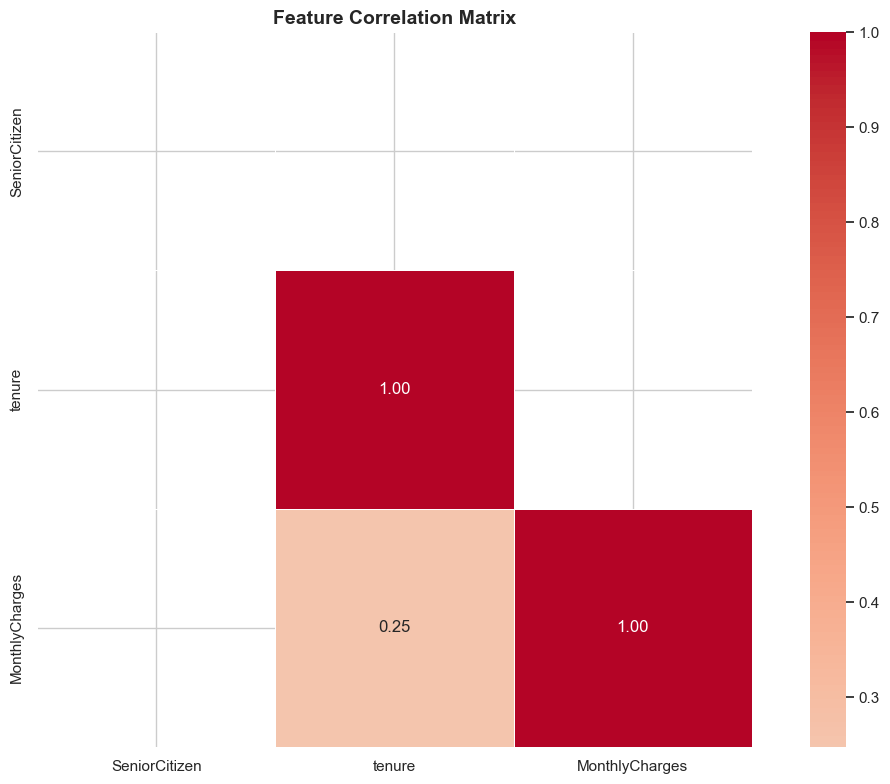

In [ ]:
# Correlation heatmapimport matplotlib.pyplot as pltimport seaborn as snsfig, ax = plt.subplots(figsize=(12, 8))corr = df[['SeniorCitizen', 'tenure', 'MonthlyCharges']].corr()mask = np.triu(np.ones_like(corr, dtype=bool), k=1)sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)plt.title('Feature Correlation Matrix', fontsize=14)plt.tight_layout()plt.show()

### 📊 Feature DistributionsHistograms show the distribution of each numerical feature. This helps identify skewness, multimodal distributions, and potential data quality issues.

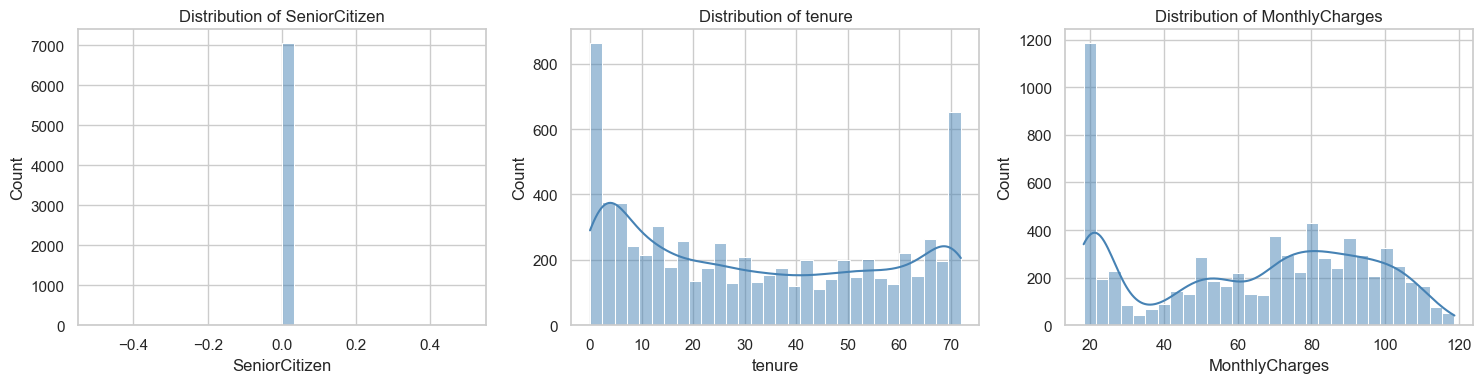

In [ ]:
# Distribution histogramsfig, axes = plt.subplots(2, 3, figsize=(15, 8))axes = axes.flatten()for i, col in enumerate(df.select_dtypes(include=[np.number]).columns[:6]):\n    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=axes[i], color='steelblue')\n    axes[i].set_title(f'Distribution of {col}')\nplt.tight_layout()\nplt.show()

## 🔀 Step 3: Data SplittingWe split the data into:- **Features (X)**: The input variables used for prediction- **Target (y)**: The value we want to predict**Problem Type Detected**: `CLASSIFICATION`Then we split into training and testing sets to evaluate model performance on unseen data.

### 🎯 Target ColumnThe target column is **`Churn`**. This is the variable we want to predict.**Problem Type**: `classification` — we'll use classification models.

### 📊 Target Variable DistributionUnderstanding the distribution of the target variable helps us choose the right evaluation metrics.

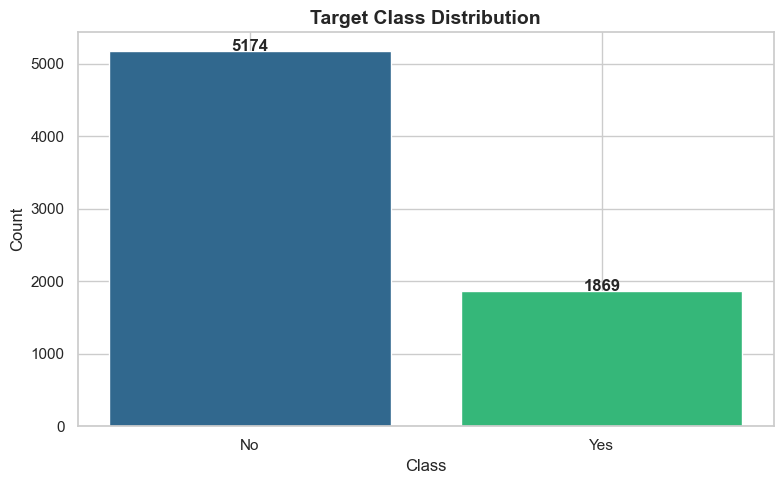

In [ ]:
# Target distributionvalue_counts = y.value_counts()fig, ax = plt.subplots(figsize=(8, 5))ax.bar(value_counts.index.astype(str), value_counts.values, color=['#2E86AB', '#A23B72', '#F18F01'])ax.set_title('Target Class Distribution')ax.set_xlabel('Class')ax.set_ylabel('Count')plt.show()

### ✂️ Train/Test Split- **Training set**: 80.0% (5634 samples, 29 features)- **Testing set**: 20.0% (1409 samples, 29 features)- **Stratified**: True✅ Stratified split ensures class proportions are preserved in both sets.

## 🧠 Step 4: Model TrainingTraining multiple classification models to find the best performer. We use **AutoGluon** — an automated ML framework that handles model selection, hyperparameter tuning, ensembling, and cross-validation automatically.

### 🤖 Models Trained (AutoGluon)A total of **5 models** were trained:- WeightedEnsemble_L2- XGBoost- LightGBM- LinearModel- RandomForest🏆 **Best Model**: `WeightedEnsemble_L2`

### 📊 AutoGluon LeaderboardThe leaderboard shows all trained models ranked by performance. AutoGluon automatically applies cross-validation and ranks models by their validation score.

In [ ]:
# AutoGluon leaderboard — all model resultsimport pandas as pdleaderboard = predictor.leaderboard(test_data, silent=True)leaderboard

model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time
WeightedEnsemble_L2,0.7970,0.7996,accuracy,0.3484,0.0323,16.8984
XGBoost,0.7928,0.7979,accuracy,0.1770,0.0116,7.9362
LightGBM,0.7921,0.7979,accuracy,0.1186,0.0154,8.6629
LinearModel,0.7921,0.7961,accuracy,0.1215,0.0168,18.8654
RandomForest,0.7771,0.7872,accuracy,0.3123,0.1328,6.1458


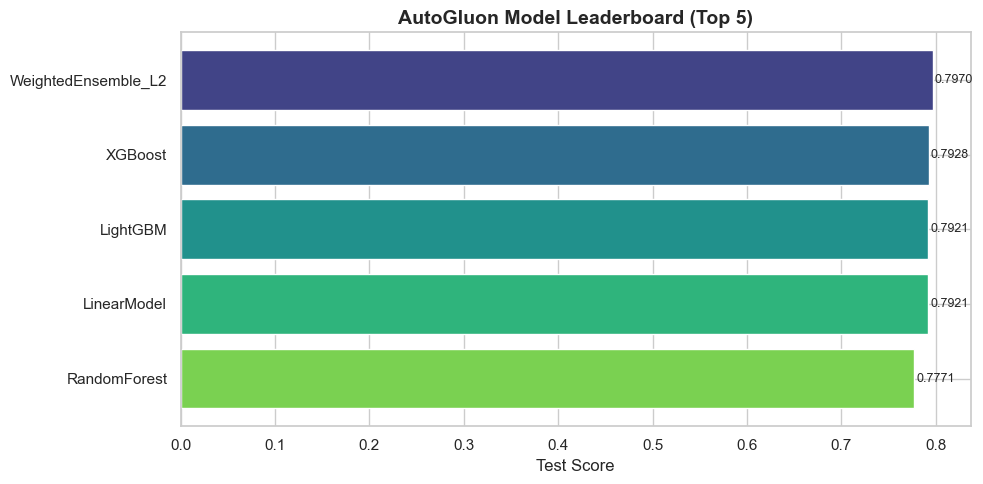

In [ ]:
# Leaderboard visualizationfig, ax = plt.subplots(figsize=(10, 6))models = ['WeightedEnsemble_L2', 'XGBoost', 'LightGBM', 'LinearModel', 'RandomForest']scores = [0.7970191625266146, 0.7927608232789212, 0.7920511000709723, 0.7920511000709723, 0.7771469127040455]ax.barh(range(len(models)), scores, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(models))))ax.set_yticks(range(len(models)))ax.set_yticklabels(models)ax.set_xlabel('Test Score')ax.set_title('Model Leaderboard')plt.show()

## 📈 Step 5: Model EvaluationEvaluating each model on the held-out test set to compare real-world performance.

In [ ]:
# Classification metrics comparisonimport pandas as pd# Results summarized below

Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
WeightedEnsemble_L2,0.7970,0.7866,0.7970,0.7730,N/A
XGBoost,0.7928,0.7828,0.7928,0.7855,N/A
LightGBM,0.7921,0.7819,0.7921,0.7639,N/A
LinearModel,0.7921,0.7828,0.7921,0.7856,N/A
RandomForest,0.7771,0.7646,0.7771,0.7679,N/A


### 🔍 Confusion Matrix — WeightedEnsemble_L2The confusion matrix shows correct vs incorrect predictions for each class.

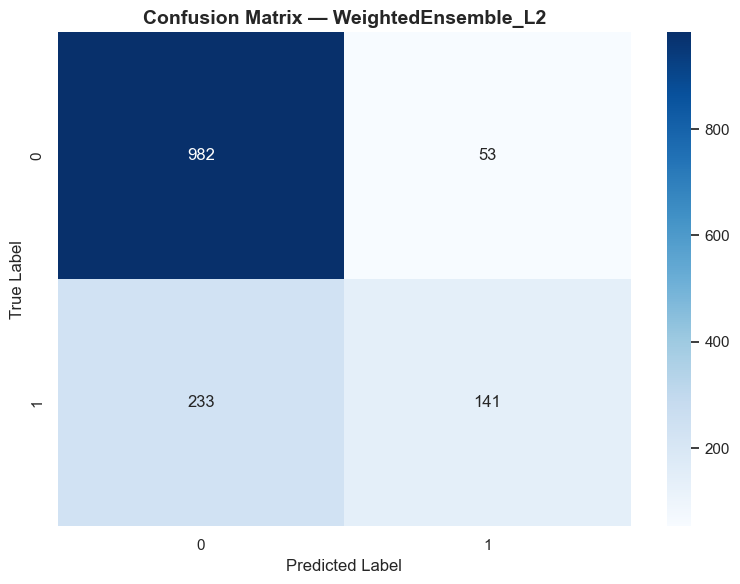

In [ ]:
# Confusion matrixfig, ax = plt.subplots(figsize=(8, 6))cm = [[982, 53], [233, 141]]\nsns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)\nax.set_title(f'Confusion Matrix — Best Model')\nax.set_xlabel('Predicted')\nax.set_ylabel('True')\nplt.show()

### ⭐ Feature Importance — WeightedEnsemble_L2Feature importance shows which variables have the most influence on predictions. This helps with interpretability and feature selection.

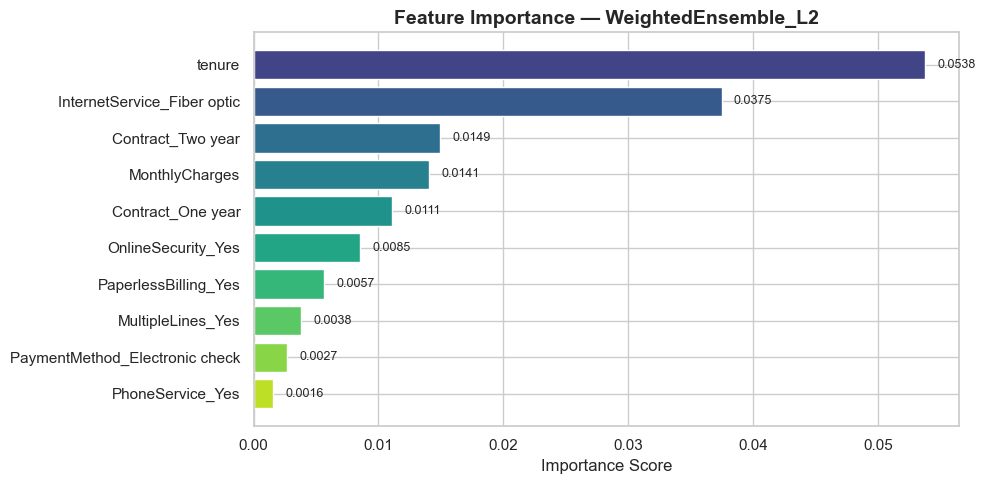

In [ ]:
# Feature importance plotfig, ax = plt.subplots(figsize=(10, 6))features = [('tenure', np.float64(0.05379701916252664)), ('InternetService_Fiber optic', np.float64(0.03747338537970195)), ('Contract_Two year', np.float64(0.014904187366926913)), ('MonthlyCharges', np.float64(0.01405251951738824)), ('Contract_One year', np.float64(0.011071682044002884)), ('OnlineSecurity_Yes', np.float64(0.008516678495386842)), ('PaperlessBilling_Yes', np.float64(0.005677785663591206)), ('MultipleLines_Yes', np.float64(0.003832505322924096)), ('PaymentMethod_Electronic check', np.float64(0.00269694819020585)), ('PhoneService_Yes', np.float64(0.0015613910574876044))]names = [f[0] for f in features]scores = [f[1] for f in features]ax.barh(range(len(names)), scores, color=plt.cm.viridis(np.linspace(0.2, 0.9, len(names))))ax.set_yticks(range(len(names)))ax.set_yticklabels(names)ax.set_xlabel('Importance')ax.set_title('Feature Importance')plt.show()

## 💡 Step 6: Recommendations & InsightsBased on the model evaluation results, here are our recommendations and insights.

### 📋 Model Performance Summary

In [ ]:
# Model performance summary# Results displayed below

model,accuracy,precision,recall,f1_score,roc_auc,leaderboard_score,prediction_time_sec
WeightedEnsemble_L2,0.7970,0.7866,0.7970,0.7730,None,0.7970,0.3484
XGBoost,0.7928,0.7828,0.7928,0.7855,None,0.7928,0.1770
LightGBM,0.7921,0.7819,0.7921,0.7639,None,0.7921,0.1186
LinearModel,0.7921,0.7828,0.7921,0.7856,None,0.7921,0.1215
RandomForest,0.7771,0.7646,0.7771,0.7679,None,0.7771,0.3123


### 🏆 Overall Verdict👍 **Good.** The model achieves accuracy of 0.7970. It's a solid baseline but improvements can be made.

### 🎯 Actionable Recommendations🎯 **Best Model**: WeightedEnsemble_L2 achieved the best performance with accuracy of 0.7970.📊 **Validation Score**: WeightedEnsemble_L2 achieved a validation score of 0.7996, indicating stable performance between validation and test sets.🔑 **Top Features**: The most important features for WeightedEnsemble_L2 are: tenure (0.0538), InternetService_Fiber optic (0.0375), Contract_Two year (0.0149), MonthlyCharges (0.0141), Contract_One year (0.0111)💡 **Feature Engineering Tip**: Consider creating interaction terms or polynomial features from the top predictors to potentially improve model performance.👍 **Good Performance**: The model shows moderate performance. To further improve:   - Try --quality balanced or --quality best for better models   - Apply feature engineering on top predictors   - Collect more training data if feasible

---*Report generated by **BlackBox AutoML** — Automated Machine Learning Pipeline*_Thank you for using BlackBox AutoML!_